# Plotting in Python
Below are some examples of plots in python using the matplotlib library.


In [2]:
import numpy as np
import math
import pandas as pd
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

## Part (a): Bisection Method

We write one general-purpose bisection routine that returns a table (as a pandas
DataFrame) of the iteration number, the endpoints $a_n,b_n$, the midpoint
$p_n$, $f(p_n)$, and the error bound $(b_n-a_n)/2$.

In [1]:
def bisection(f, a, b, tol=1e-5, max_iter=100):
    """Bisection method. Returns (root, DataFrame of iterations)."""
    fa = f(a)
    if fa == 0:
        return a, None
    if f(b) == 0:
        return b, None
    if fa * f(b) > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")

    rows = []
    p_prev = None
    for n in range(1, max_iter + 1):
        p = (a + b) / 2
        fp = f(p)
        err = (b - a) / 2
        rows.append({
            "n": n, "a_n": a, "b_n": b, "p_n": p,
            "f(p_n)": fp, "error bound (b-a)/2": err
        })
        if fp == 0 or err < tol:
            break
        if fa * fp > 0:
            a, fa = p, fp
        else:
            b = p
    df = pd.DataFrame(rows).set_index("n")
    return p, df

### (i) Find an approximation to within $10^{-5}$ to a value in [0.5, 1.5] with $e^x - 2 = \cos(e^x - 2)$.

In [3]:
g1 = lambda x: (math.exp(x) - 2) - math.cos(math.exp(x) - 2)

root1, table1 = bisection(g1, 0.5, 1.5, tol=1e-5)
print(f"Approximate root: p = {root1:.8f}")
print(f"Number of iterations: {len(table1)}")
table1

Approximate root: p = 1.00762177
Number of iterations: 17


,a_n,b_n,p_n,f(p_n),error bound (b-a)/2
n,,,,,
1,0.500000,1.500000,1.000000,-0.034656,0.500000
2,1.000000,1.500000,1.250000,1.409976,0.250000
3,1.000000,1.250000,1.125000,0.609080,0.125000
4,1.000000,1.125000,1.062500,0.266982,0.062500
5,1.000000,1.062500,1.031250,0.111148,0.031250
6,1.000000,1.031250,1.015625,0.037003,0.015625
7,1.000000,1.015625,1.007812,0.000864,0.007812
8,1.000000,1.007812,1.003906,-0.016973,0.003906
9,1.003906,1.007812,1.005859,-0.008073,0.001953


### (ii) First positive solution of $x = \tan x$

---



Let $f(x) = \tan x - x$. The first positive root (other than the trivial $x=0$)
lies in the third "branch" of the tangent function, between $\pi$ and
$3\pi/2 \approx 4.712$ (avoiding the asymptote at $\pi/2$). We bracket it in
$[4.4, 4.6]$, where $f(4.4) < 0$ and $f(4.6) > 0$.

In [4]:
f2 = lambda x: math.tan(x) - x

print("f(4.4) =", f2(4.4), "  f(4.6) =", f2(4.6))

root2, table2 = bisection(f2, 4.4, 4.6, tol=1e-5)
print(f"Approximate root: p = {root2:.8f}")
print(f"Number of iterations: {len(table2)}")
table2

f(4.4) = -1.3036762193502547   f(4.6) = 4.260174895648046
Approximate root: p = 4.49341431
Number of iterations: 15


,a_n,b_n,p_n,f(p_n),error bound (b-a)/2
n,,,,,
1,4.400000,4.600000,4.500000,0.137332,0.100000
2,4.400000,4.500000,4.450000,-0.726731,0.050000
3,4.450000,4.500000,4.475000,-0.341933,0.025000
4,4.475000,4.500000,4.487500,-0.116078,0.012500
5,4.487500,4.500000,4.493750,0.006887,0.006250
6,4.487500,4.493750,4.490625,-0.055491,0.003125
7,4.490625,4.493750,4.492188,-0.024531,0.001563
8,4.492188,4.493750,4.492969,-0.008880,0.000781
9,4.492969,4.493750,4.493359,-0.001011,0.000391


## Part (b): Fixed Point Iteration

General fixed point iteration routine $p_{n} = g(p_{n-1})$, returning a table of
iterates and the successive difference $|p_n - p_{n-1}|$ as the stopping
criterion.

In [5]:
def fixed_point(g, p0, tol=1e-5, max_iter=100):
    """Fixed point iteration. Returns (fixed point, DataFrame of iterations)."""
    rows = [{"n": 0, "p_n": p0, "|p_n - p_(n-1)|": np.nan}]
    p_prev = p0
    for n in range(1, max_iter + 1):
        p = g(p_prev)
        diff = abs(p - p_prev)
        rows.append({"n": n, "p_n": p, "|p_n - p_(n-1)|": diff})
        if diff < tol:
            p_prev = p
            break
        p_prev = p
    df = pd.DataFrame(rows).set_index("n")
    return p_prev, df

### (i) $$e^x + x = 7$$

Rearranged as a fixed point problem:

$$x = \ln(7 - x) = g(x).$$

(Starting guess $p_0 = 1$; note

$$|g'(x)| = \frac{1}{7-x} < 1$$

near the root, so the iteration converges.)

In [6]:
g_i = lambda x: math.log(7 - x)

root_b1, table_b1 = fixed_point(g_i, p0=1.0, tol=1e-5)
print(f"Approximate solution: x = {root_b1:.8f}")
print(f"Check: e^x + x = {math.exp(root_b1) + root_b1:.8f}")
print(f"Number of iterations: {len(table_b1) - 1}")
table_b1

Approximate solution: x = 1.67282071
Check: e^x + x = 6.99999376
Number of iterations: 8


,p_n,|p_n - p_(n-1)|
n,,
0,1.000000,NaN
1,1.791759,0.791759
2,1.650242,0.141517
3,1.677051,0.026809
4,1.672027,0.005024
5,1.672971,0.000943
6,1.672794,0.000177
7,1.672827,0.000033
8,1.672821,0.000006


### (ii) $$e^x + \sin(x) = 4$$

Rearranged as:

$$x = \ln(4 - \sin x) = g(x).$$

(Starting guess $p_0 = 1$.)

In [7]:
g_ii = lambda x: math.log(4 - math.sin(x))

root_b2, table_b2 = fixed_point(g_ii, p0=1.0, tol=1e-5)
print(f"Approximate solution: x = {root_b2:.8f}")
print(f"Check: e^x + sin(x) = {math.exp(root_b2) + math.sin(root_b2):.8f}")
print(f"Number of iterations: {len(table_b2) - 1}")
table_b2

Approximate solution: x = 1.12997952
Check: e^x + sin(x) = 3.99999654
Number of iterations: 6


,p_n,|p_n - p_(n-1)|
n,,
0,1.000000,NaN
1,1.150106,0.150106
2,1.127262,0.022844
3,1.130356,0.003094
4,1.129929,0.000427
5,1.129988,0.000059
6,1.129980,0.000008


## Part (c): Newton's Method — Colebrook Equation

The Colebrook equation for the Darcy friction factor $f$ is

$$\frac{1}{\sqrt{f}} = -2\log_{10}\!\left(\frac{\epsilon}{3.7D} + \frac{2.51}{Re\sqrt{f}}\right)$$

We solve for $f$ by defining

$$F(f) = \frac{1}{\sqrt{f}} + 2\log_{10}\!\left(\frac{\epsilon}{3.7D} + \frac{2.51}{Re\sqrt{f}}\right) = 0$$

and applying Newton's method $f_{n+1} = f_n - F(f_n)/F'(f_n)$, using a
finite-difference (numerical) derivative so the same code is easy to reuse for
different $D$, $\epsilon$, $Re$.

In [10]:
def newton(F, p0, tol=1e-5, max_iter=100, h=1e-8):
    """Newton's method with a numerical derivative. Returns (root, DataFrame)."""
    rows = []
    p = p0
    for n in range(1, max_iter + 1):
        Fp = F(p)
        dF = (F(p + h) - F(p - h)) / (2 * h)
        p_new = p - Fp / dF
        err = abs(p_new - p)
        rows.append({"n": n, "p_n": p_new, "F(p_n)": Fp, "|p_n - p_(n-1)|": err})
        if err < tol:
            p = p_new
            break
        p = p_new
    df = pd.DataFrame(rows).set_index("n")
    return p, df


def colebrook_F(f, D, eps, Re):
    return 1 / math.sqrt(f) + 2 * math.log10(eps / (3.7 * D) + 2.51 / (Re * math.sqrt(f)))

### (i) $$D = 0.3\text{ m}, \quad \epsilon = 0.0002\text{ m}, \quad Re = 10^5$$

A reasonable initial guess comes from the Swamee–Jain approximation, but a
simple guess like $f_0 = 0.02$ works fine for Newton's method here.

In [12]:
D, eps, Re = 0.3, 0.0002, 1e5
F1 = lambda f: colebrook_F(f, D, eps, Re)

f_root, table_c1 = newton(F1, p0=0.02, tol=1e-8)
print(f"Darcy friction factor f = {f_root:.8f}")
print(f"Number of iterations: {len(table_c1)}")
table_c1

Darcy friction factor f = 0.02098370
Number of iterations: 4


,p_n,F(p_n),|p_n - p_(n-1)|
n,,,
1,0.020949,1.780182e-01,9.491663e-04
2,0.020984,6.039128e-03,3.449612e-05
3,0.020984,7.377412e-06,4.224368e-08
4,0.020984,1.103118e-11,6.316475e-14


### (ii) Darcy number vs. Reynolds number, $Re \in [10^4, 10^8]$

$D$ and $\epsilon$ are held fixed at the values above. We sweep $Re$ on a log
scale, solving for $f$ with Newton's method at each value, then plot
$f$ vs. $Re$ with a logarithmic horizontal axis (this is the classic
"Moody chart" curve for a single relative roughness $\epsilon/D$).

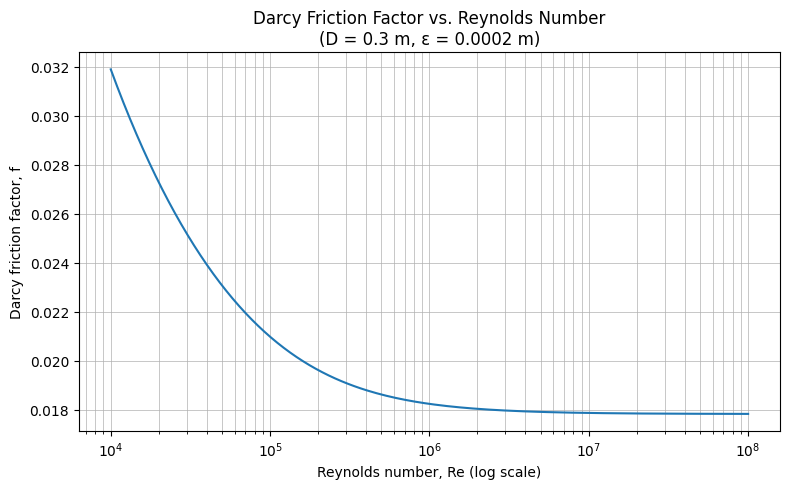

In [13]:
Re_values = np.logspace(4, 8, 200)
f_values = []

f_guess = 0.02
for Re_i in Re_values:
    F_i = lambda f, Re_i=Re_i: colebrook_F(f, D, eps, Re_i)
    f_i, _ = newton(F_i, p0=f_guess, tol=1e-10)
    f_values.append(f_i)
    f_guess = f_i  # warm-start the next Newton solve with the previous root

f_values = np.array(f_values)

plt.figure(figsize=(8, 5))
plt.plot(Re_values, f_values)
plt.xscale('log')
plt.xlabel('Reynolds number, Re (log scale)')
plt.ylabel('Darcy friction factor, f')
plt.title(f'Darcy Friction Factor vs. Reynolds Number\n(D = {D} m, ε = {eps} m)')
plt.grid(True, which="both", ls="-", lw=0.5)
plt.tight_layout()
plt.show()

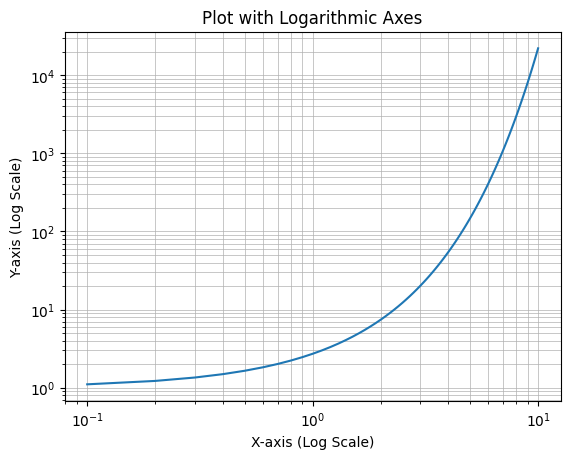

In [14]:
x = np.linspace(0.1, 10, 100)
y = np.exp(x) # Example data showing exponential growth

plt.plot(x, y)
plt.xscale('log') # Set x-axis to logarithmic scale
plt.yscale('log') # Set y-axis to logarithmic scale
plt.title('Plot with Logarithmic Axes')
plt.xlabel('X-axis (Log Scale)')
plt.ylabel('Y-axis (Log Scale)')
plt.grid(True, which="both", ls="-", lw=0.5) # Add grid for better visualization
plt.show()


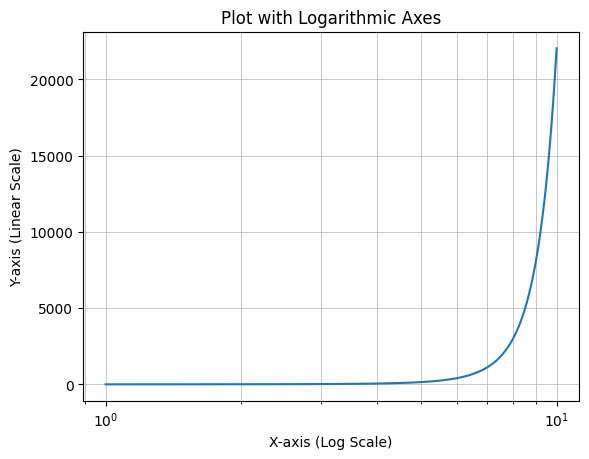

In [15]:
x = np.linspace(1,10,100)
y = np.exp(x) # Example data showing exponential growth

plt.plot(x, y)
plt.xscale('log') # Set x-axis to logarithmic scale
#plt.yscale('log') # Set y-axis to logarithmic scale
plt.title('Plot with Logarithmic Axes')
plt.xlabel('X-axis (Log Scale)')
plt.ylabel('Y-axis (Linear Scale)')
plt.grid(True, which="both", ls="-", lw=0.5) # Add grid for better visualization
plt.show()
